# Import Data

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
# Import data and observe shape and columns
chess_data_raw = pd.read_csv("data/games.csv")
print(chess_data_raw.shape)
print(chess_data_raw.columns)
chess_data_raw.head(10)

(20058, 16)
Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='object')


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5
5,MsoDV9wj,False,1.504240e+12,1.504240e+12,5,draw,draw,10+0,trelynn17,1250,franklin14532,1002,e4 c5 Nf3 Qa5 a3,B27,Sicilian Defense: Mongoose Variation,4
6,qwU9rasv,True,1.504230e+12,1.504230e+12,33,resign,white,10+0,capa_jr,1520,daniel_likes_chess,1423,d4 d5 e4 dxe4 Nc3 Nf6 f3 exf3 Nxf3 Nc6 Bb5 a6 ...,D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10
7,RVN0N3VK,False,1.503680e+12,1.503680e+12,9,resign,black,15+30,daniel_likes_chess,1413,soultego,2108,e4 Nc6 d4 e5 d5 Nce7 c3 Ng6 b4,B00,Nimzowitsch Defense: Kennedy Variation | Link...,5
8,dwF3DJHO,True,1.503510e+12,1.503510e+12,66,resign,black,15+0,ehabfanri,1439,daniel_likes_chess,1392,e4 e5 Bc4 Nc6 Nf3 Nd4 d3 Nxf3+ Qxf3 Nf6 h3 Bc5...,C50,Italian Game: Schilling-Kostic Gambit,6
9,afoMwnLg,True,1.503440e+12,1.503440e+12,119,mate,white,10+0,daniel_likes_chess,1381,mirco25,1209,e4 d5 exd5 Qxd5 Nc3 Qe5+ Be2 Na6 d4 Qf5 Bxa6 b...,B01,Scandinavian Defense: Mieses-Kotroc Variation,4


# Clean data
- Remove IDs (main ID and player IDs)

In [54]:
chess_data = chess_data_raw.drop(columns=["id", "white_id", "black_id"])

# Drop all non-rated games for doing rating analysis
chess_data = chess_data[chess_data["rated"] == True]
chess_data["winner"] = chess_data["winner"].map({"black": 0, "white": 1})

# Descriptive Statistics

In [ ]:
print("Players of Black Ratings ---------------")
print(chess_data["black_rating"].mean())
print(chess_data["black_rating"].median())
print()
print("Players of White Ratings ---------------")
print(chess_data["white_rating"].mean())
print(chess_data["white_rating"].median())
print()
# Make array with every player (both black or white)
all_players = pd.concat([chess_data['white_rating'], chess_data['black_rating']], ignore_index=True)
print("All Player Ratings ---------------")
print(all_players.mean())
print(all_players.median())
print()

Players of Black Ratings ---------------
1593.5031878675334
1573.0

Players of White Ratings ---------------
1597.1020117610647
1577.0

All Player Ratings ---------------
1595.302599814299
1575.0


(array([ 278., 1409., 4351., 7539., 7618., 5888., 3320., 1480.,  396.,
          31.]),
 array([ 784. ,  967.8, 1151.6, 1335.4, 1519.2, 1703. , 1886.8, 2070.6,
        2254.4, 2438.2, 2622. ]),
 <BarContainer object of 10 artists>)

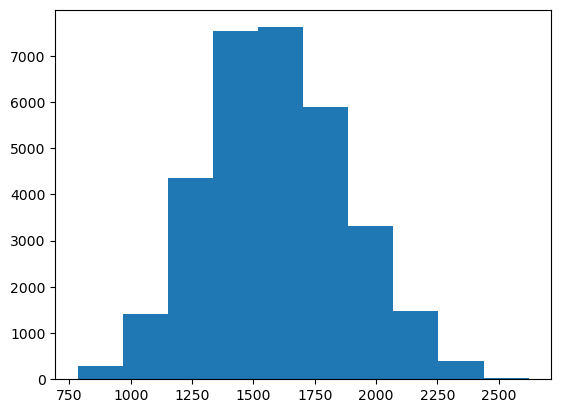

In [74]:
plt.hist(all_players, bins=10)

# Correlation

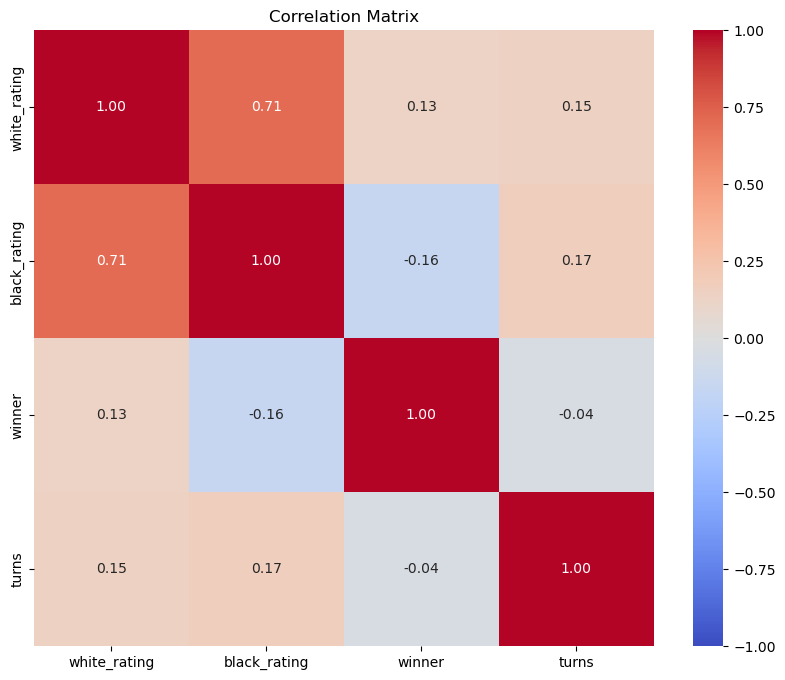

In [38]:
chess_corr_data = chess_data[["white_rating", "black_rating", "winner", "turns"]]

corr_matrix = chess_corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmax=1, vmin=-1)
plt.title("Correlation Matrix")
plt.show()

# Opening Evaluation

In [ ]:
# Find the stats for each ECO
eco_stats = chess_data.groupby("opening_eco").agg(
    white_rating_mean=("white_rating", "mean"),
    white_rating_std=("white_rating", "std"),
    black_rating_mean=("black_rating", "mean"),
    black_rating_std=("black_rating", "std"),
    count=("opening_eco", "size")
)

47

In [52]:
most_popular = eco_stats.nlargest(20, "count")
least_popular = eco_stats[eco_stats["count"] == 1]

most_popular

,white_rating_mean,white_rating_std,black_rating_mean,black_rating_std,count
opening_eco,,,,,
A00,1436.684145,270.479128,1490.149813,293.035885,801
C00,1566.980743,260.836707,1547.447043,286.054734,727
D00,1528.164154,283.840973,1551.050251,286.225308,597
B01,1532.117547,289.958197,1526.860307,308.139414,587
C41,1533.804618,240.503144,1494.978686,225.083131,563
C20,1385.660448,206.730201,1401.283582,218.463329,536
A40,1585.581213,299.697182,1547.181996,280.630711,511
B20,1538.226293,262.212967,1606.303879,270.690590,464
B00,1538.214286,271.199328,1476.448052,275.762914,462
